In [123]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob

In [124]:
# 1. Загрузка изображений (предполагается, что они в папке 'images' и названы frame1.jpg ... frame8.jpg)
image_paths = sorted(glob('../data/lab2/frame*.jpg'))
images = [cv2.imread(p) for p in image_paths]
gray_images = [cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in images]

# Выравнивание яркости (гистограмма)
# Параметры
patch_size = 16         # размер патча (дескриптора)
half_patch = patch_size // 2
max_points = 500         # макс. число ключевых точек на изображение
harris_thresh_ratio = 0.01  # порог для углов Харриса (доля от максимума)
nms_kernel_size = 5      # размер ядра для подавления немаксимумов
ratio_thresh = 0.7       # порог для ratio-теста при сопоставлении
ransac_iter = 1000       # итераций RANSAC
ransac_thresh = 5.0      # порог inlier в пикселях

In [125]:
def convolution(image, window):
    start = int((len(window[0])-1)/2)
    result = np.zeros((image.shape))
    for i in range(start,image.shape[0]-start):
        for j in range(start,image.shape[1]-start):
            result[i,j] = np.sum(image[i-start:i+start+1,j-start:j+start+1]*window)
    return result
def reflect_borders(image, n): #image - изображение (не RGB либо отдельный канал), n - размерность ядра свертки
    h, w = image.shape
    conv_image = np.zeros((h+n//2+n//2, w+n//2+n//2),dtype=image.dtype)
    for j in range(h):
        for k in range(w):
            conv_image[j+n//2][k+n//2] = image[j][k]
    for j in range (n//2):
        for k in range(w+n//2+n//2):
            if (k < n//2):
                conv_image[j][k] = image[0][0]
            elif (k-n//2 >= w):
                conv_image[j][k] = image[0][w-1]
            elif (k < w+n//2):
                conv_image[j][k] = image[0][k-n//2]
    for j in range (h+n//2, h+n//2+n//2):
        for k in range(w+n//2+n//2):
            if (k < n//2):
                conv_image[j][k] = image[h-1][0]
            elif (k-n//2 >= w):
                conv_image[j][k] = image[h-1][w-1]
            elif (k < w+n//2):
                conv_image[j][k] = image[h-1][k-n//2]
    for j in range (n//2):
        for k in range(n//2 ,h+n//2):
            if (k-n//2 >= h):
                conv_image[k][j] = image[h-1][w-1]
            elif (k < h+n//2):
                conv_image[k][j] = image[k-n//2][0]
    for j in range (w+n//2, w+n//2+n//2):
        for k in range(n//2 ,h+n//2):
            if (k-n//2 >= h):
                conv_image[k][j] = image[h-1][w-1]
            elif (k < h+n//2):
                conv_image[k][j] = image[k-n//2][0]
    return conv_image

In [126]:
def harris_corners(input_img, k = 0.01, window_size=3, n=500):
    # Создаём цветную копию для визуализации
    output_img = cv2.cvtColor(input_img.copy(), cv2.COLOR_GRAY2RGB)

    offset = window_size // 2
    h, w = input_img.shape
    y_range = h - offset
    x_range = w - offset

    # Градиенты через numpy
    dy, dx = np.gradient(input_img.astype(np.float32))
    Ixx = dx ** 2
    Ixy = dy * dx
    Iyy = dy ** 2

    all_corners = []  # будет хранить [x, y, r] для всех обработанных пикселей

    # Проходим по всем пикселям, где окно целиком помещается
    for y in range(offset, y_range):
        for x in range(offset, x_range):
            # Границы окна
            y1, y2 = y - offset, y + offset + 1
            x1, x2 = x - offset, x + offset + 1

            # Суммы произведений градиентов в окне
            Sxx = Ixx[y1:y2, x1:x2].sum()
            Sxy = Ixy[y1:y2, x1:x2].sum()
            Syy = Iyy[y1:y2, x1:x2].sum()

            # Отклик Харриса
            det = Sxx * Syy - Sxy ** 2
            trace = Sxx + Syy
            r = det - k * trace ** 2

            all_corners.append([x, y, r])

    # Сортируем все точки по убыванию отклика и берём первые n
    all_corners.sort(key=lambda p: p[2], reverse=True)
        
    corner_list = all_corners[:n]
    corners_fin = [row[:2] + row[2+1:] for row in corner_list]
    # Отмечаем отобранные точки красным на выходном изображении
    for x, y, _ in corner_list:
        output_img[y, x] = (255, 0, 0)
    
    return corners_fin, output_img

In [127]:
harris, img = harris_corners(gray_images[0], 0.01, 3, 1000)
harris, img2 = harris_corners(gray_images[1], 0.01, 3, 1000)

In [128]:
harris

[[375, 310],
 [375, 311],
 [342, 287],
 [342, 288],
 [376, 310],
 [347, 286],
 [374, 311],
 [308, 284],
 [375, 309],
 [367, 284],
 [374, 310],
 [374, 312],
 [343, 287],
 [397, 339],
 [343, 288],
 [375, 312],
 [346, 286],
 [374, 313],
 [342, 289],
 [347, 285],
 [345, 287],
 [376, 309],
 [348, 286],
 [368, 288],
 [353, 289],
 [398, 337],
 [373, 313],
 [373, 284],
 [354, 332],
 [397, 340],
 [229, 415],
 [334, 306],
 [365, 352],
 [376, 311],
 [353, 288],
 [345, 286],
 [225, 541],
 [229, 416],
 [373, 311],
 [353, 287],
 [368, 287],
 [163, 506],
 [162, 505],
 [390, 366],
 [367, 283],
 [373, 312],
 [352, 289],
 [341, 284],
 [366, 351],
 [396, 339],
 [383, 284],
 [162, 517],
 [386, 288],
 [390, 365],
 [377, 310],
 [347, 287],
 [228, 415],
 [347, 284],
 [398, 336],
 [334, 305],
 [374, 309],
 [352, 290],
 [377, 311],
 [369, 288],
 [309, 285],
 [344, 287],
 [163, 518],
 [347, 295],
 [308, 283],
 [346, 284],
 [361, 342],
 [309, 284],
 [85, 435],
 [237, 406],
 [354, 331],
 [352, 287],
 [381, 292],


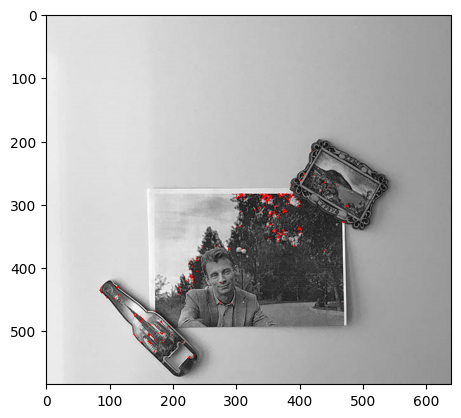

In [129]:
plt.imshow(img2)

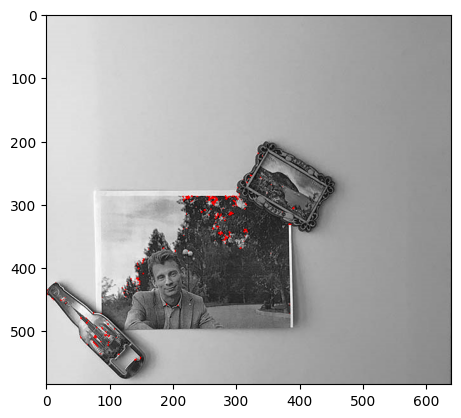

In [130]:
plt.imshow(img)

In [135]:
def extract_descriptors(image, points, patch_size=16):
    """
    Извлекает нормализованные патчи для заданных точек.
    points: список или массив, каждый элемент содержит [x, y, ...] (координаты могут быть первыми двумя)
    Возвращает:
        descriptors: массив формы (M, patch_size*patch_size)
        filtered_points: список отобранных точек (x, y) в виде кортежей
    """
    half = patch_size // 2
    h, w = image.shape
    descriptors = []
    filtered_points = []
    
    for pt in points:
        # Извлекаем x, y (предполагаем, что они первые два элемента)
        x = int(pt[0])
        y = int(pt[1])
        
        # Проверка границ
        if x < half or x >= w - half or y < half or y >= h - half:
            continue
        
        # Вырезаем патч
        patch = image[y-half:y+half, x-half:x+half].astype(np.float32)
        
        # Дополнительная проверка формы (на случай нецелых границ)
        if patch.shape != (patch_size, patch_size):
            continue
        
        # Нормализация
        mean = patch.mean()
        std = patch.std()
        if std > 1e-6:
            patch_norm = (patch - mean) / std
        else:
            patch_norm = patch - mean
        
        descriptors.append(patch_norm.flatten())
        filtered_points.append((x, y))
    
    # Преобразуем в массив numpy
    if len(descriptors) == 0:
        # Если ни одна точка не прошла, возвращаем пустые массивы
        return np.array([]), []
    
    return np.array(descriptors), filtered_points

In [136]:
# 4. Сопоставление дескрипторов между двумя изображениями (с ratio-тестом)
def match_descriptors(desc1, desc2, ratio_thresh=0.7):
    # Вычисляем матрицу расстояний (SSD)
    dist_mat = np.linalg.norm(desc1[:, None, :] - desc2[None, :, :], axis=2)

    matches = []
    for i in range(len(desc1)):
        # Сортируем расстояния
        sorted_idx = np.argsort(dist_mat[i])
        best_idx = sorted_idx[0]
        best_dist = dist_mat[i, best_idx]
        second_best_dist = dist_mat[i, sorted_idx[1]]

        # Ratio test
        if best_dist < ratio_thresh * second_best_dist:
            matches.append((i, best_idx))  # (индекс в desc1, индекс в desc2)

    return np.array(matches)

In [137]:
# 5. Оценка преобразования (R, t) по парам точек с RANSAC
def estimate_transform_ransac(pts1, pts2, ransac_iter=1000, thresh=5.0):

    best_inliers = []
    best_R = np.eye(2)
    best_t = np.zeros(2)
    n_points = len(pts1)

    if n_points < 2:
        return best_R, best_t, []

    for _ in range(ransac_iter):
        # Выбираем 2 случайные пары
        idx = np.random.choice(n_points, 2, replace=False)
        p1 = pts1[idx]
        p2 = pts2[idx]

        # Оценка R,t по двум точкам (метод SVD)
        # Центрируем
        centroid1 = p1.mean(axis=0)
        centroid2 = p2.mean(axis=0)
        p1_centered = p1 - centroid1
        p2_centered = p2 - centroid2

        H = p1_centered.T @ p2_centered
        U, S, Vt = np.linalg.svd(H)
        R = Vt.T @ U.T
        # Проверка на отражение
        if np.linalg.det(R) < 0:
            Vt[-1, :] *= -1
            R = Vt.T @ U.T
        t = centroid2 - R @ centroid1

        # Считаем inliers
        projected = (R @ pts1.T).T + t
        errors = np.linalg.norm(projected - pts2, axis=1)
        inliers = np.where(errors < thresh)[0]

        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_R, best_t = R, t

    # Уточняем модель по всем inliers
    if len(best_inliers) >= 2:
        p1_in = pts1[best_inliers]
        p2_in = pts2[best_inliers]

        centroid1 = p1_in.mean(axis=0)
        centroid2 = p2_in.mean(axis=0)
        p1_centered = p1_in - centroid1
        p2_centered = p2_in - centroid2

        H = p1_centered.T @ p2_centered
        U, S, Vt = np.linalg.svd(H)
        R = Vt.T @ U.T
        if np.linalg.det(R) < 0:
            Vt[-1, :] *= -1
            R = Vt.T @ U.T
        t = centroid2 - R @ centroid1

    return best_R, best_t, best_inliers

In [157]:
# 6. Основной цикл по парам изображений
keypoints_list = []
descriptors_list = []

print("Детектирование ключевых точек и построение дескрипторов...")
for i, gray in enumerate(gray_images):
    kp, _ = harris_corners(gray, 0.01, 3, max_points)
    desc, filtered_kp = extract_descriptors(gray, kp, patch_size)
    keypoints_list.append(filtered_kp)
    descriptors_list.append(desc)
    print(f"Изображение {i+1}: исходно {len(kp)} точек, после фильтрации {len(filtered_kp)}")

# Оценка относительных движений между соседними кадрами
num_images = len(gray_images)
rel_motions = []  # каждый элемент: (R_rel, t_rel) между i и i+1

print("\nСопоставление и оценка преобразований...")
for i in range(len(gray_images) - 1):
    print(f"Пара {i+1}-{i+2}")
    kp1 = np.array(keypoints_list[i])      
    kp2 = np.array(keypoints_list[i+1])    
    desc1 = descriptors_list[i]
    desc2 = descriptors_list[i+1]

    matches = match_descriptors(desc1, desc2, ratio_thresh)
    if len(matches) < 2:
        print(f"  Недостаточно сопоставлений ({len(matches)}), пропускаем")
        rel_motions.append((np.eye(2), np.zeros(2)))
        continue

    pts1 = kp1[matches[:, 0]]
    pts2 = kp2[matches[:, 1]]

    R_rel, t_rel, inliers = estimate_transform_ransac(pts1, pts2, ransac_iter, ransac_thresh)
    rel_motions.append((R_rel, t_rel))
    print(f"  Сопоставлений: {len(matches)}, inliers: {len(inliers)}")


Детектирование ключевых точек и построение дескрипторов...
Изображение 1: исходно 500 точек, после фильтрации 492
Изображение 2: исходно 500 точек, после фильтрации 500
Изображение 3: исходно 500 точек, после фильтрации 500
Изображение 4: исходно 500 точек, после фильтрации 500
Изображение 5: исходно 500 точек, после фильтрации 500
Изображение 6: исходно 500 точек, после фильтрации 500
Изображение 7: исходно 500 точек, после фильтрации 491
Изображение 8: исходно 500 точек, после фильтрации 497

Сопоставление и оценка преобразований...
Пара 1-2
  Сопоставлений: 135, inliers: 135
Пара 2-3
  Сопоставлений: 100, inliers: 100
Пара 3-4
  Сопоставлений: 210, inliers: 210
Пара 4-5
  Сопоставлений: 169, inliers: 169
Пара 5-6
  Сопоставлений: 372, inliers: 372
Пара 6-7
  Сопоставлений: 146, inliers: 146
Пара 7-8
  Сопоставлений: 268, inliers: 268


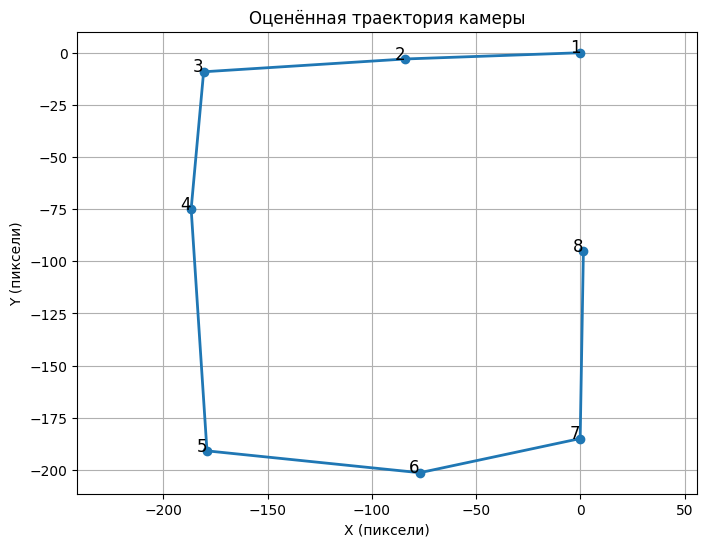

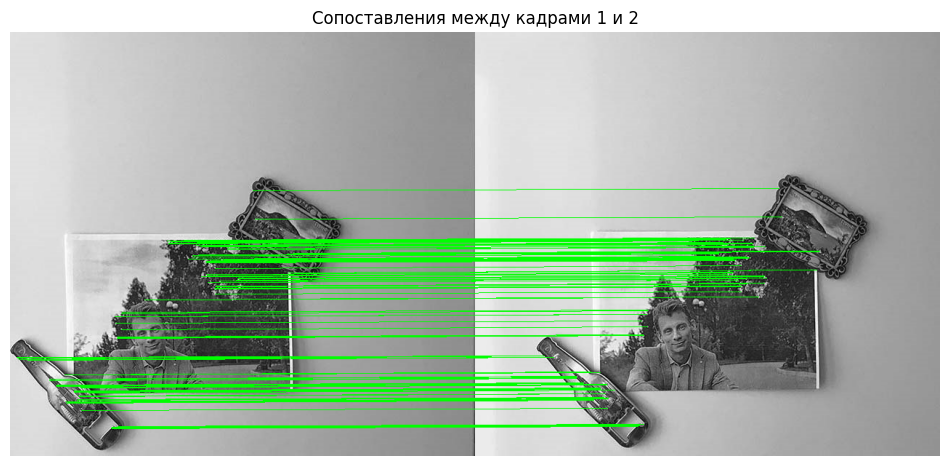

In [164]:

# 7. Построение траектории камеры
# Начальное положение: центр (0,0), ориентация I
positions = [(0.0, 0.0)]
R_cur = np.eye(2)   # текущая ориентация камеры (из мировых в камерные)
C_cur = np.zeros(2) # текущее положение камеры в мировых координатах

for (R_rel, t_rel) in rel_motions:
    R_new = R_cur @ R_rel.T
    C_new = C_cur - R_cur @ R_rel.T @ t_rel
    positions.append(tuple(C_new))
    R_cur, C_cur = R_new, C_new

positions = np.array(positions)

# 8. Визуализация траектории
plt.figure(figsize=(8, 6))
plt.plot(positions[:, 0], -positions[:, 1], 'o-', linewidth=2, markersize=6)
plt.title('Оценённая траектория камеры')
plt.xlabel('X (пиксели)')
plt.ylabel('Y (пиксели)')
plt.axis('equal')
plt.grid(True)
for i, (x, y) in enumerate(positions):
    plt.text(x, -y, f'{i+1}', fontsize=12, ha='right')
plt.show()

# (Опционально) Отображение сопоставлений для первой пары
if len(rel_motions) > 0:
    i = 0
    kp1 = keypoints_list[i]
    kp2 = keypoints_list[i+1]
    desc1 = descriptors_list[i]
    desc2 = descriptors_list[i+1]
    matches = match_descriptors(desc1, desc2, ratio_thresh)
    if len(matches) > 0:
        # Рисуем линии сопоставлений
        img1 = cv2.cvtColor(gray_images[i], cv2.COLOR_GRAY2BGR)
        img2 = cv2.cvtColor(gray_images[i+1], cv2.COLOR_GRAY2BGR)
        h, w = img1.shape[:2]
        vis = np.hstack((img1, img2))
        for m in matches:
            x1, y1 = kp1[m[0]]
            x2, y2 = kp2[m[1]]
            cv2.line(vis, (int(x1), int(y1)), (int(x2)+w, int(y2)), (0,255,0), 1)
        plt.figure(figsize=(12,6))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title(f'Сопоставления между кадрами {i+1} и {i+2}')
        plt.axis('off')
        plt.show()